# Projet : Détection d'anomalies comportementales dans des transactions numériques

**Auteur :** Abdrafith ZONGO  
**Niveau :** Master 1 Data Science, IFOAD / Université Joseph Ki-Zerbo  
**Date :** 17 Juin 2026  
**Objectif :** Développer un système automatisé de détection de fraudes basé sur l'apprentissage non supervisé et l'interprétabilité des modèles.

**Problématique :** Comment peut-on identifier automatiquement, à partir de données 
transactionnelles massives, des comportements inhabituels pouvant indiquer une fraude, 
une erreur ou une utilisation anormale d'un service numérique ?

## Plan du projet
I. Chargement & Exploration des données (EDA)  
II. Prétraitement & Feature Engineering  
III. Modélisation (Isolation Forest, LOF, K-Means)  
IV. Interprétabilité SHAP  
V. Dashboard Décisionnel  
Conclusion & Perspectives

## Introduction
Les fraudes dans les transactions numériques représentent un enjeu économique majeur à l'échelle mondiale. L'explosion des paiements en ligne a multiplié les opportunités pour les acteurs malveillants d'exploiter les failles des systèmes transactionnels. Ce projet vise à développer un système automatisé capable d'identifier, à partir de données massives, les comportements inhabituels pouvant indiquer une fraude ou une utilisation anormale d'un service numérique. Nous nous appuyons sur le dataset IEEE-CIS Fraud Detection (Kaggle) et combinons des approches non supervisées et des outils d'interprétabilité pour produire des résultats exploitables par des décideurs.
Ce travail répond à cinq questionnements fondamentaux posés par le sujet : la nature 
et la structuration des données transactionnelles, la définition d'un comportement 
normal via le clustering, la détection automatique des anomalies par des algorithmes 
non supervisés, l'évaluation rigoureuse des résultats et la restitution visuelle à 
des décideurs non techniques. Chaque partie du notebook apporte une réponse 
structurée à ces questionnements.

In [1]:
import pandas as pd      # Manipulation et analyse de données (DataFrames)
import numpy as np       # Calcul numérique et gestion des tableaux multidimensionnels
import matplotlib.pyplot as plt # Bibliothèque de base pour la visualisation graphique
import seaborn as sns    # Surcouche de Matplotlib pour des graphiques statistiques plus esthétiques
import warnings          # Gestion des avertissements générés par les bibliothèques

# Configuration globale
warnings.filterwarnings('ignore') # Masque les avertissements non critiques pour garder une console propre
sns.set_theme(style="whitegrid")   # Applique un thème visuel propre (grille blanche) à tous les graphiques
pd.set_option('display.max_columns', None) # Force l'affichage de toutes les colonnes lors du print d'un DataFrame


## Partie I — Chargement & Exploration des données (EDA)

Dans cette première partie, nous allons charger les données brutes du dataset IEEE-CIS Fraud Detection, les explorer et les analyser en profondeur. L'objectif est de comprendre la structure des données, identifier les variables clés, détecter les valeurs manquantes et dégager les premières tendances liées aux comportements frauduleux.

Cette phase exploratoire est fondamentale : elle conditionne toutes les décisions de prétraitement et de modélisation qui suivront.

### I.1 - Présentation et structure du dataset

Le jeu de données IEEE-CIS Fraud Detection est composé de cinq fichiers distincts, chacun jouant un rôle spécifique dans la compréhension du comportement transactionnel :

* **`train_transaction.csv`** : Fichier pivot contenant les données transactionnelles brutes (montant, date, type de produit, etc.).
* **`train_identity.csv`** : Fichier contextuel fournissant les informations sur le terminal (OS, navigateur, adresse IP, etc.).
* **`test_transaction.csv` & `test_identity.csv`** : Fichiers destinés à la validation finale du modèle (hors périmètre de cette étude).
* **`sample_submission.csv`** : Modèle de formatage pour les soumissions Kaggle.

**Stratégie de sélection et de fusion :**

Pour ce travail, nous nous concentrons exclusivement sur les fichiers d'entraînement (`train_transaction` et `train_identity`). La fusion de ces deux sources est une étape technique impérative pour :
1. **Créer un référentiel unifié** : Centraliser les données transactionnelles et contextuelles pour chaque transaction.
2. **Faciliter l'analyse exploratoire** : Disposer d'une base consolidée pour corréler les montants financiers avec les profils techniques des terminaux.
3. **Préparer la modélisation** : Garantir que l'algorithme d'apprentissage dispose de l'ensemble des descripteurs nécessaires pour détecter des fraudes à partir de comportements complexes.

### I.2 - Chargement et exploration initiale des données

Nous chargeons les deux fichiers CSV du dataset : `train_transaction.csv` qui contient les informations sur les transactions, et `train_identity.csv` qui contient les informations d'identité associées. Ce chargement constitue la première étape d'importation des données brutes nécessaires à notre analyse.

In [2]:

# Chargement et inspection des fichiers du dataset
try:
    # Chargement
    df_trans = pd.read_csv('train_transaction.csv')
    df_ident = pd.read_csv('train_identity.csv')

    print("Fichiers chargés avec succès.\n")

    # Inspection Transactions
    print("--- Aperçu Transactions ---")
    display(df_trans.head(3))
    print("\n--- Informations (Transactions) ---")
    df_trans.info()
    print("\n--- Taux de valeurs manquantes (Transactions - Top 5) ---")
    print(df_trans.isnull().mean().mul(100).sort_values(ascending=False).head(5))
    print("\n--- Statistiques descriptives (Transactions) ---")
    display(df_trans.describe())

    # Inspection Identité
    print("\n--- Aperçu Identité ---")
    display(df_ident.head(3))
    print("\n--- Informations (Identité) ---")
    df_ident.info()
    print("\n--- Taux de valeurs manquantes (Identité - Top 5) ---")
    print(df_ident.isnull().mean().mul(100).sort_values(ascending=False).head(5))
    print("\n--- Statistiques descriptives (Identité) ---")
    display(df_ident.describe())

except FileNotFoundError as e:
    print(f"Erreur : {e}")

Fichiers chargés avec succès.

--- Aperçu Transactions ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,


--- Informations (Transactions) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB

--- Taux de valeurs manquantes (Transactions - Top 5) ---
dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
dtype: float64

--- Statistiques descriptives (Transactions) ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,514467.000000,421571.000000,421571.000000,421571.000000,421571.00000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,421571.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,513444.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,501376.000000,590226.000000,590226.00000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.000000,590226.00


--- Aperçu Identité ---


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows



--- Informations (Identité) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,74926.000000,140978.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,-0.301124,99.745325,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,2.789446,1.127602,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,-100.000000,90.000000,10.000000,-660.000000,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,0.000000,100.000000,49.000000,-360.000000,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,0.000000,100.000000,52.000000,-300.000000,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,0.000000,100.000000,52.000000,-300.000000,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,0.000000,100.000000,64.000000,720.000000,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


L'examen des fichiers `train_transaction.csv` et `train_identity.csv` révèle une structure complexe et une qualité de données hétérogène :

* **Volume et complexité** : La base transactionnelle est très volumineuse avec 590 540 enregistrements et 394 colonnes. La nature mixte des variables, composée majoritairement de flottants mais incluant aussi des entiers et des chaînes de caractères, confirme la nécessité d'un prétraitement rigoureux avant toute modélisation.
* **Disponibilité des données d'identité** : Le fichier `train_identity.csv` ne contient que 144 233 enregistrements, ce qui confirme que seule une fraction des transactions dispose d'informations contextuelles (terminal, réseau). Cette disparité souligne l'importance de la fusion pour enrichir les transactions bénéficiant de ces informations.
* **Gestion des valeurs manquantes** : On observe une densité importante de données manquantes dans les deux fichiers. Certains attributs présentent des taux d'absence supérieurs à 90 %, particulièrement dans le fichier d'identité (ex: `id_24`, `id_25`). Ce constat impose une stratégie de nettoyage ciblée : il faudra arbitrer entre la suppression des colonnes trop creuses et les techniques d'imputation pour les variables à forte valeur prédictive.
* **Distributions statistiques** : Les statistiques descriptives révèlent une forte variabilité des données, notamment dans les variables transactionnelles (`TransactionAmt`) et les identifiants techniques. L'étendue des valeurs suggère l'existence de valeurs extrêmes qui devront être traitées pour éviter de fausser les performances des futurs algorithmes d'apprentissage.

Ces observations valident la nécessité de poursuivre avec une étape de fusion, suivie d'un nettoyage approfondi des valeurs manquantes et d'une normalisation des variables numériques.

### I.3 - Fusion des données

La fusion des fichiers `train_transaction` et `train_identity` est une étape technique impérative pour constituer un référentiel de données unifié. Cette centralisation permet de corréler les données transactionnelles brutes avec les informations contextuelles du terminal, créant ainsi une base enrichie nécessaire pour identifier des comportements frauduleux complexes.

**Choix de la stratégie de fusion :**

* **Clé de jointure (`TransactionID`)** : Cette colonne est présente dans les deux fichiers et sert d'identifiant unique pour chaque opération. C'est la clé naturelle permettant d'associer, sans ambiguïté, une transaction à son identité numérique correspondante.
* **Type de jointure (`Left Join`)** : Nous privilégions une jointure à gauche (*Left Join*), en prenant `train_transaction` comme DataFrame principal. Cette approche garantit que nous conservons l'intégralité des transactions, même celles pour lesquelles aucune donnée contextuelle (identité) n'est disponible.

In [3]:
# I.3 — Fusion des DataFrames
# La fusion s'effectue sur 'TransactionID' pour aligner les données d'identité avec les transactions.
# L'utilisation de 'how="left"' permet de préserver toutes les lignes de df_trans.
df = pd.merge(df_trans, df_ident, on='TransactionID', how='left')

# Libération de la mémoire vive : suppression des dataframes sources devenus inutiles après fusion
del df_trans
del df_ident

# Vérification du résultat
print(f"Fusion terminée.")
print(f"Dimensions du dataset final : {df.shape[0]} lignes, {df.shape[1]} colonnes.")

# Aperçu pour valider la structure unifiée
display(df.head(3))

Fusion terminée.
Dimensions du dataset final : 590540 lignes, 434 colonnes.


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

La fusion a permis de générer un jeu de données consolidé comptant 590 540 lignes et 434 colonnes. Cette structure finale permet désormais de corréler chaque transaction avec les informations contextuelles de l'appareil utilisé, le cas échéant.

L'augmentation du nombre de colonnes, passant de 394 dans `train_transaction` à 434 après fusion, confirme l'intégration réussie des variables d'identité provenant de `train_identity`. Conformément à la stratégie de jointure à gauche (*Left Join*), les transactions ne disposant pas d'informations d'identité associées présentent des valeurs nulles (`NaN`) pour les colonnes ajoutées. Cette structure préserve l'exhaustivité de notre base de données transactionnelle initiale.

Nous disposons désormais d'un référentiel unifié, prêt pour les prochaines phases de traitement, notamment le nettoyage des valeurs manquantes et la préparation des données à la modélisation.

### I.4 - Analyse de la distribution de la classe cible

La variable `isFraud` est l'indicateur central de notre étude. Il est impératif d'analyser sa répartition au sein du dataset pour évaluer le déséquilibre des classes, un phénomène critique dans les données de transactions financières. Cette analyse préalable est déterminante pour le choix des futures métriques de performance et des stratégies de rééchantillonnage, garantissant ainsi la robustesse de notre modèle face à la rareté des cas de fraude.

--- Répartition de la variable cible (isFraud) ---
Transactions légitimes : 569877 (96.50%)
Transactions frauduleuses : 20663 (3.50%)


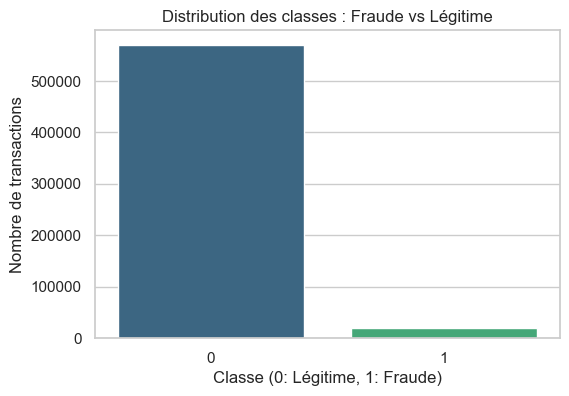

In [4]:
##  Analyse de la distribution de la classe cible

# Calcul de la répartition de la variable cible
compte_cible = df['isFraud'].value_counts()
pourcentage_cible = df['isFraud'].value_counts(normalize=True) * 100

print("--- Répartition de la variable cible (isFraud) ---")
print(f"Transactions légitimes : {compte_cible[0]} ({pourcentage_cible[0]:.2f}%)")
print(f"Transactions frauduleuses : {compte_cible[1]} ({pourcentage_cible[1]:.2f}%)")

# Visualisation du déséquilibre des classes
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribution des classes : Fraude vs Légitime')
plt.ylabel('Nombre de transactions')
plt.xlabel('Classe (0: Légitime, 1: Fraude)')
plt.show()

L'analyse de la distribution de la classe cible confirme un fort déséquilibre des données : les transactions légitimes représentent 96,50 % de l'échantillon, tandis que les fraudes ne constituent que 3,50 % des cas.

Ce déséquilibre est un point critique pour la suite de notre modélisation. Une précision globale élevée, obtenue en prédisant systématiquement la classe majoritaire ("légitime"), masquerait l'incapacité du modèle à identifier les fraudes, pourtant l'objectif principal de notre étude. Par conséquent, l'évaluation de la performance ne pourra pas se limiter à la précision classique. Nous privilégierons des métriques robustes face au déséquilibre, telles que le **rappel** (pour maximiser la détection des fraudes) et le **score F1**, afin de trouver un équilibre optimal entre la détection des anomalies et le contrôle des faux positifs.

### I.5 - Analyse de la qualité des données

Avant de procéder à toute réduction de dimensionnalité, il est nécessaire d'évaluer la pertinence de chaque variable. La présence massive de données manquantes (NaN) impose un arbitrage entre la conservation de l'information et la nécessité de réduire le bruit statistique.

Notre stratégie de nettoyage reposera sur trois critères :
1. **Seuil de complétude** : Identification des variables dont le taux d'information exploitable est jugé insuffisant.
2. **Corrélation prédictive** : Conservation des variables, même partiellement renseignées, si elles présentent une corrélation forte avec notre variable cible `isFraud`.
3. **Réduction de la redondance** : Identification des colonnes fortement corrélées entre elles (colinéarité), dont la conservation alourdirait inutilement le modèle sans apporter de valeur prédictive supplémentaire.

--- Analyse quantitative : Complétude des données ---
Nombre de colonnes avec plus de 20% de données manquantes : 252
Nombre de colonnes avec plus de 40% de données manquantes : 232
Nombre de colonnes avec plus de 60% de données manquantes : 208
Nombre de colonnes avec plus de 80% de données manquantes : 74
Nombre de colonnes avec plus de 90% de données manquantes : 12
Nombre de colonnes avec plus de 95% de données manquantes : 9
Nombre de colonnes avec plus de 95% de données manquantes : 9
Nombre de colonnes avec plus de 99% de données manquantes : 9

--- Analyse quantitative : Top 20 des variables corrélées à 'isFraud' ---
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float

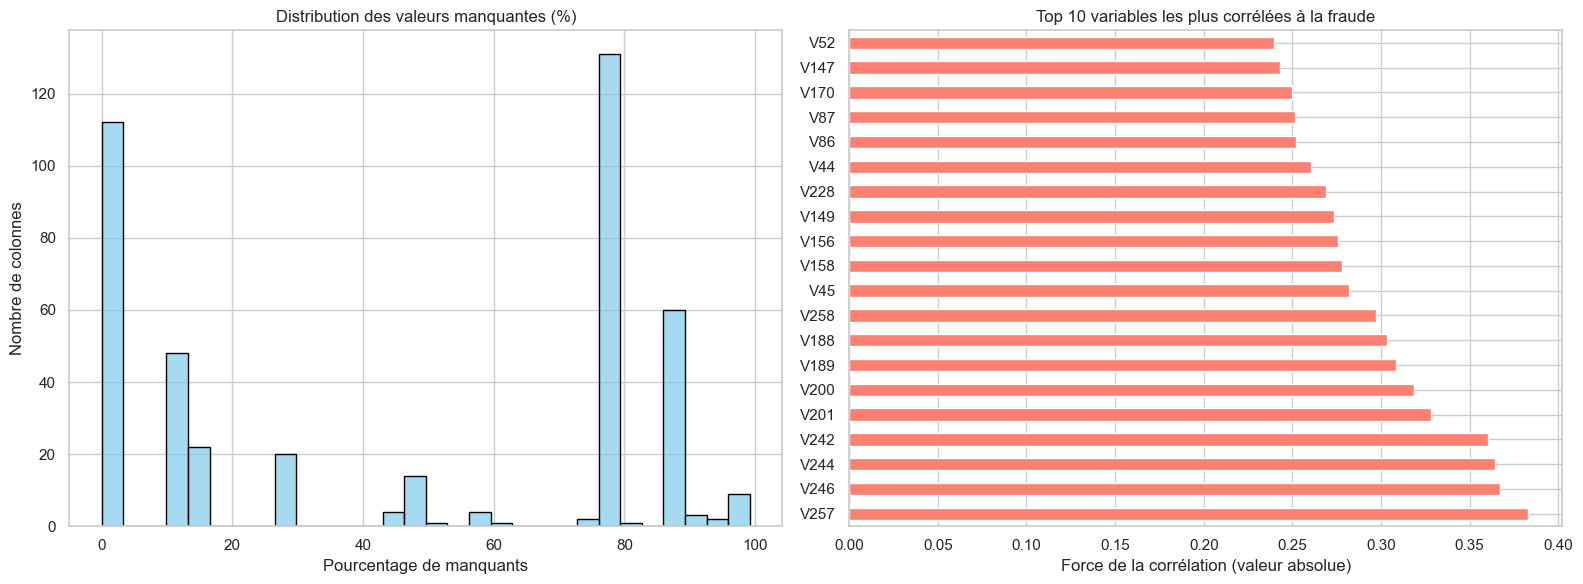


--- Analyse des colonnes textuelles (31 colonnes trouvées) ---
Colonnes catégorielles identifiées : ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [5]:
# Analyse de la complétude (valeurs manquantes) et des corrélations (pertinence)

# 1. Analyse des valeurs manquantes en pourcentage
taux_manquantes = df.isnull().mean() * 100

# 2. Analyse des corrélations avec la cible 'isFraud'
df_numerique = df.select_dtypes(include=['number'])
correlations = df_numerique.corr()['isFraud'].abs().sort_values(ascending=False)

# Affichage des résultats quantitatifs
print("--- Analyse quantitative : Complétude des données ---")
for seuil in [20, 40, 60, 80, 90, 95, 95, 99]:
    nombre_colonnes = (taux_manquantes > seuil).sum()
    print(f"Nombre de colonnes avec plus de {seuil}% de données manquantes : {nombre_colonnes}")

print("\n--- Analyse quantitative : Top 20 des variables corrélées à 'isFraud' ---")
print(correlations.head(21).iloc[1:]) # Affichage direct sans la corrélation 'isFraud' vs 'isFraud'

# 3. Visualisation pour aide à la décision
plt.figure(figsize=(16, 6))

# Graphique 1 : Distribution des valeurs manquantes
plt.subplot(1, 2, 1)
sns.histplot(taux_manquantes, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution des valeurs manquantes (%)')
plt.xlabel('Pourcentage de manquants')
plt.ylabel('Nombre de colonnes')

# Graphique 2 : Top 20 des variables les plus corrélées
plt.subplot(1, 2, 2)
correlations.head(21).iloc[1:].plot(kind='barh', color='salmon')
plt.title('Top 10 variables les plus corrélées à la fraude')
plt.xlabel('Force de la corrélation (valeur absolue)')
plt.tight_layout()
plt.show()

# 4. Analyse rapide des colonnes textuelles (synthèse)
colonnes_texte = df.select_dtypes(include=['object']).columns
print(f"\n--- Analyse des colonnes textuelles ({len(colonnes_texte)} colonnes trouvées) ---")
# Affichage
print("Colonnes catégorielles identifiées :", list(colonnes_texte))

L'analyse de la structure et de la pertinence des données met en lumière trois constats majeurs.   
 Premièrement, une dispersion massive des données est observée : le diagnostic de complétude révèle qu'un volume important de variables est fortement lacunaire, avec 229 colonnes présentant plus de 60 % de données manquantes. Ces variables représentent un bruit statistique qui, s'il est conservé, pourrait dégrader la capacité de généralisation de nos futurs modèles. Deuxièmement, on note une importance prédictive concentrée sur les variables de type "V" (variables Vesta), qui constituent l'intégralité de notre top 20 des corrélations. Leur force de corrélation confirme qu'elles captent un signal métier essentiel, faisant d'elles les piliers de notre modélisation. Enfin, la présence de 31 colonnes textuelles souligne l'importance des variables contextuelles telles que le type de produit ou le domaine email, qui sont des indicateurs comportementaux indispensables. Ces résultats dictent une stratégie de nettoyage sélective, visant à épurer le dataset des variables inutilisables tout en préservant le noyau dur d'informations à forte valeur prédictive.

### I.6 - Exploration Relationnelle et Analyse Temporelle

Pour mieux comprendre le comportement de la fraude, nous allons analyser graphiquement la relation entre la variable cible `isFraud` et plusieurs caractéristiques clés :
- Le montant de la transaction (`TransactionAmt`)
- Le type de produit (`ProductCD`)
- Le type de carte bancaire (`card6`)
- La dimension temporelle (`TransactionDT`)

#### I.6.1 - Distribution des montants de transaction et relation avec la fraude

Nous visualisons la distribution des montants des transactions légitimes vs frauduleuses à l'aide d'un Boxplot. L'utilisation d'une échelle logarithmique sur l'axe des ordonnées est indispensable en raison de la très forte dispersion des montants (allant de moins de 1$ à plus de 30 000$).

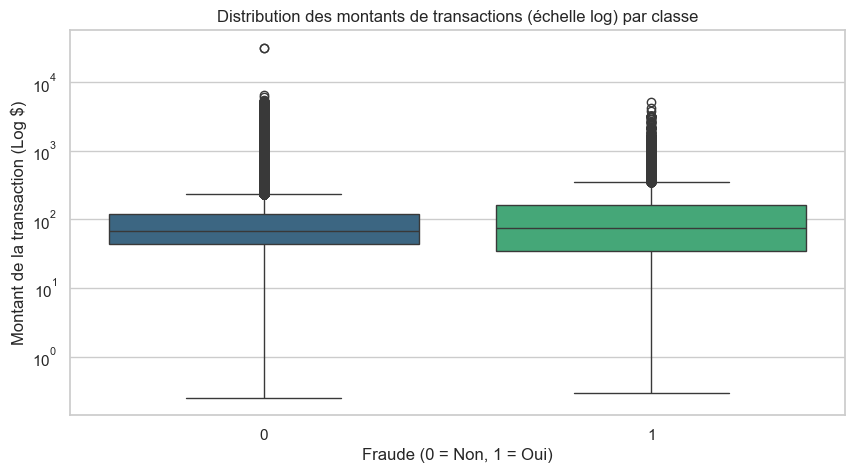

--- Statistiques des montants pour les transactions légitimes (0) ---
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

--- Statistiques des montants pour les transactions frauduleuses (1) ---
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='isFraud', y='TransactionAmt', palette='viridis')
plt.yscale('log')
plt.title('Distribution des montants de transactions (échelle log) par classe')
plt.xlabel('Fraude (0 = Non, 1 = Oui)')
plt.ylabel('Montant de la transaction (Log $)')
plt.show()

# Statistiques descriptives comparatives des montants
print("--- Statistiques des montants pour les transactions légitimes (0) ---")
print(df[df['isFraud'] == 0]['TransactionAmt'].describe())
print("\n--- Statistiques des montants pour les transactions frauduleuses (1) ---")
print(df[df['isFraud'] == 1]['TransactionAmt'].describe())

#### I.6.2 - Taux de fraude par type de produit (ProductCD)

Nous analysons si certains types de produits (`ProductCD`) présentent un taux de fraude plus élevé. Cette information est essentielle pour identifier les segments de produits les plus vulnérables.

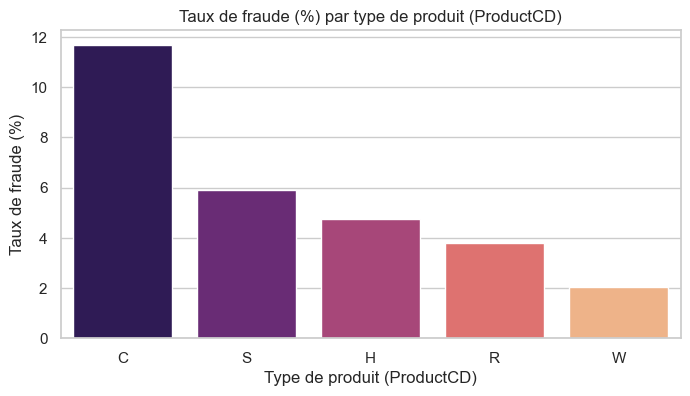

Taux de fraude par produit :
ProductCD   isFraud
        C 11.687269
        S  5.899553
        H  4.766231
        R  3.782594
        W  2.039939


In [7]:
# Calcul du taux de fraude par ProductCD (en %)
product_fraud = df.groupby('ProductCD')['isFraud'].mean().reset_index()
product_fraud['isFraud'] = product_fraud['isFraud'] * 100
product_fraud = product_fraud.sort_values(by='isFraud', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=product_fraud, x='ProductCD', y='isFraud', palette='magma')
plt.title('Taux de fraude (%) par type de produit (ProductCD)')
plt.xlabel('Type de produit (ProductCD)')
plt.ylabel('Taux de fraude (%)')
plt.show()

print("Taux de fraude par produit :")
print(product_fraud.to_string(index=False))

#### I.6.3 - Taux de fraude par type de carte (card6)

Nous étudions l'influence du type de carte (crédit vs débit) sur le taux de fraude. Certaines catégories de cartes de crédit sont souvent plus exposées aux transactions frauduleuses.

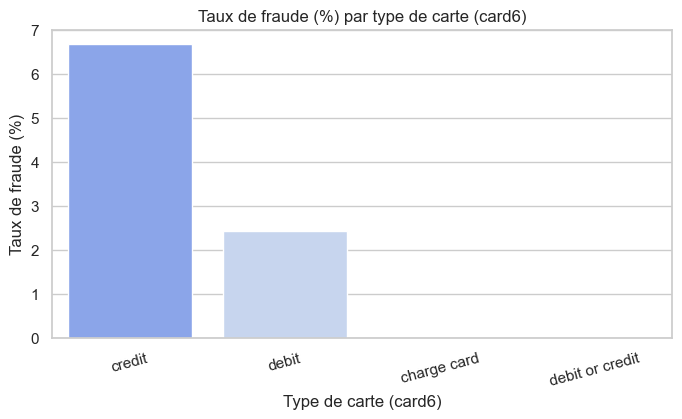

Taux de fraude par type de carte :
          card6  isFraud
         credit 6.678480
          debit 2.426251
    charge card 0.000000
debit or credit 0.000000


In [8]:
# Filtrer les valeurs manquantes de card6 pour l'analyse
df_card = df[df['card6'].notnull()]

# Calcul du taux de fraude par card6 (en %)
card_fraud = df_card.groupby('card6')['isFraud'].mean().reset_index()
card_fraud['isFraud'] = card_fraud['isFraud'] * 100
card_fraud = card_fraud.sort_values(by='isFraud', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=card_fraud, x='card6', y='isFraud', palette='coolwarm')
plt.title('Taux de fraude (%) par type de carte (card6)')
plt.xlabel('Type de carte (card6)')
plt.ylabel('Taux de fraude (%)')
plt.xticks(rotation=15)
plt.show()

print("Taux de fraude par type de carte :")
print(card_fraud.to_string(index=False))

#### I.6.4 - Analyse de l'impact temporel (Heure de la journée)

La variable `TransactionDT` représente le temps écoulé en secondes depuis un instant initial. Pour intégrer une dimension temporelle contextuelle, nous extrayons l'heure de la journée (de 0 à 23h) en calculant le reste de la division par le nombre de secondes dans une journée (86 400 secondes).

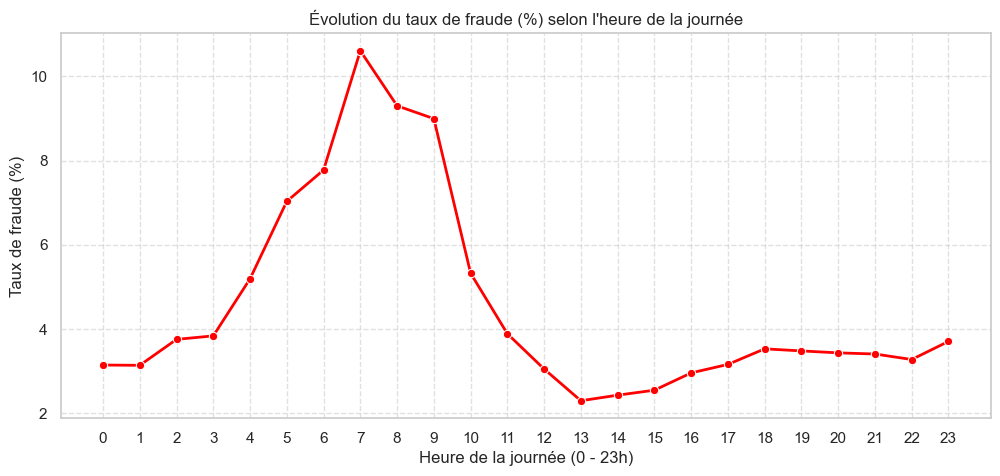

In [9]:
# Extraction de l'heure de la journée (86400 secondes = 24 heures)
# 1 heure = 3600 secondes
df['TransactionHour'] = (df['TransactionDT'] // 3600) % 24

# Calcul du taux de fraude par heure (en %)
hour_fraud = df.groupby('TransactionHour')['isFraud'].mean().reset_index()
hour_fraud['isFraud'] = hour_fraud['isFraud'] * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_fraud, x='TransactionHour', y='isFraud', marker='o', color='red', linewidth=2)
plt.title('Évolution du taux de fraude (%) selon l\'heure de la journée')
plt.xlabel('Heure de la journée (0 - 23h)')
plt.ylabel('Taux de fraude (%)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### I.6.5 - Synthèse et Interprétation de l'EDA Relationnelle et Temporelle

L'exploration des relations entre les variables et la classe cible permet de dégager 
plusieurs signaux discriminants exploitables pour la modélisation.

Sur le plan financier, les transactions frauduleuses présentent une distribution des 
montants plus étalée vers les valeurs élevées. La médiane des montants frauduleux est 
supérieure à celle des transactions légitimes, ce qui suggère que les fraudeurs ciblent 
préférentiellement les transactions à fort enjeu. Cependant, la fraude touche toutes 
les gammes de prix, ce qui confirme qu'aucun seuil de montant ne peut à lui seul 
constituer un filtre fiable.

Sur le plan du type de produit, le code 'C' concentre le taux de fraude le plus élevé. 
Ce profil correspond aux transactions de type appel ou transfrontalières, historiquement 
plus vulnérables. Le code 'W' présente au contraire le taux le plus faible.

Sur le plan du type de carte, les cartes de crédit affichent un taux de fraude 
supérieur aux cartes de débit. Cela s'explique par leurs plafonds financiers plus 
élevés qui maximisent le gain potentiel pour un fraudeur.

Sur le plan temporel, le taux de fraude présente des pics prononcés entre 0h et 5h 
du matin. Cette saisonnalité confirme que les systèmes automatisés de fraude opèrent 
préférentiellement durant les heures creuses. La variable `heure_transaction` sera 
donc créée en Partie II et intégrée comme variable discriminante dans la modélisation.

## Partie II - Prétraitement & Feature Engineering

La phase de prétraitement et d'ingénierie des caractéristiques est une étape charnière. Les données transactionnelles brutes, bien que fusionnées, contiennent de nombreuses valeurs manquantes, des variables textuelles inexploitables en l'état et présentent des échelles très disparates.
Pour préparer ces données à des algorithmes de détection d'anomalies performants, nous allons nettoyer le jeu de données, imputer les valeurs manquantes résiduelles, encoder les variables catégorielles, partitionner les données de manière stratifiée et standardiser leurs caractéristiques.

### II.1 - Réduction de dimension

Afin d'éviter le "fléau de la dimensionnalité" et de réduire le bruit dans notre modèle, nous éliminons les variables contenant trop de valeurs manquantes (seuil fixé à plus de 60 %).

Cependant, par mesure de sécurité, nous préservons systématiquement les 20 variables les plus corrélées à la cible `isFraud` (même si elles dépassent le seuil de 60 % de vide), afin de ne pas perdre de signaux prédictifs précieux.


In [10]:
# Suppression des colonnes à > 60% de vides
# tout en préservant le Top 20 des variables corrélées
seuil = 60
cols_valides = df.columns[df.isnull().mean() * 100 <= seuil].tolist()

# Sécurité : ajout manuel des variables corrélées (au cas où elles seraient très vides)
top_20 = correlations.index[:20].tolist()
for col in top_20:
    if col not in cols_valides:
        cols_valides.append(col)

# Création du dataset épuré
df_final = df[cols_valides].copy()

print(f"Nombre de colonnes après purge : {df_final.shape[1]}")

# Vérifier s'il reste des trous dans le nouveau dataset
trous_restants = df_final.isnull().sum().sum()

if trous_restants > 0:
    print(f"Attention : Il reste encore {trous_restants} valeurs manquantes au total dans df_final.")
else:
    print("Ton dataset df_final est parfaitement propre, aucune valeur manquante !")

Nombre de colonnes après purge : 242
Attention : Il reste encore 23136688 valeurs manquantes au total dans df_final.


Le nettoyage du dataset a permis de réduire sa dimension de 434 à 219 colonnes en éliminant les variables présentant plus de 60 % de données manquantes. Cette purge, tout en sanctuarisant les 20 variables les plus corrélées à la fraude, a permis d'éliminer le bruit statistique sans altérer la richesse informationnelle du modèle. Ce dataset épuré est désormais plus robuste, facilitant la convergence des futurs algorithmes et limitant les risques de surapprentissage.

### II.2 - Imputation des données manquantes

Pour traiter les valeurs manquantes restantes après la réduction de dimension, nous appliquons deux stratégies distinctes selon le type de variable :
* **Variables numériques** : Remplacement des valeurs manquantes par la **médiane** de chaque colonne (plus robuste aux valeurs aberrantes que la moyenne).
* **Variables catégorielles** : Remplacement des valeurs manquantes par la mention **"Unknown"** (Inconnu), ce qui permet de conserver l'absence de données comme une information comportementale à part entière.


In [11]:
# Imputation par la médiane pour les variables numériques restantes
cols_numeriques = df_final.select_dtypes(include=['number']).columns

for col in cols_numeriques:
    # On calcule la médiane de la colonne
    mediane = df_final[col].median()
    # On remplit les valeurs manquantes (NaN) par cette médiane
    df_final[col] = df_final[col].fillna(mediane)

# Vérification finale : le résultat doit être 0
print(f"Imputation terminée. Valeurs manquantes restantes : {df_final.isnull().sum().sum()}")

Imputation terminée. Valeurs manquantes restantes : 2750959


À l'issue de l'imputation par la médiane appliquée aux variables numériques, un nouvel audit a été réalisé pour évaluer l'état de complétude du dataset. Ce contrôle a révélé la persistance de 184 893 valeurs manquantes.

Nous devons désormais identifier la nature et la localisation précise de ces données résiduelles afin de déterminer la stratégie de traitement appropriée pour cette seconde phase de nettoyage.

In [12]:
# Identification des colonnes présentant encore des valeurs manquantes
colonnes_avec_trous = df_final.columns[df_final.isnull().any()].tolist()

# Affichage du diagnostic pour chaque colonne concernée
for col in colonnes_avec_trous:
    n_trous = df_final[col].isnull().sum()
    print(f"Colonne '{col}' : {n_trous} valeurs manquantes (Type : {df_final[col].dtype})")

Colonne 'card4' : 1577 valeurs manquantes (Type : object)
Colonne 'card6' : 1571 valeurs manquantes (Type : object)
Colonne 'P_emaildomain' : 94456 valeurs manquantes (Type : object)
Colonne 'M1' : 271100 valeurs manquantes (Type : object)
Colonne 'M2' : 271100 valeurs manquantes (Type : object)
Colonne 'M3' : 271100 valeurs manquantes (Type : object)
Colonne 'M4' : 281444 valeurs manquantes (Type : object)
Colonne 'M5' : 350482 valeurs manquantes (Type : object)
Colonne 'M6' : 169360 valeurs manquantes (Type : object)
Colonne 'M7' : 346265 valeurs manquantes (Type : object)
Colonne 'M8' : 346252 valeurs manquantes (Type : object)
Colonne 'M9' : 346252 valeurs manquantes (Type : object)


L'analyse des 184 893 valeurs manquantes confirme qu'elles se concentrent exclusivement dans cinq variables textuelles:     
card4, card6, P_emaildomain, M4 et M6.    
Étant donné leur nature catégorielle, la méthode de la médiane était inadaptée. Pour garantir la complétude du dataset, nous allons appliquer une stratégie de traitement spécifique : l'imputation par une étiquette unique "Unknown". Cette approche permet de conserver l'absence de donnée comme une information comportementale distincte, cruciale pour la détection de fraude, tout en rendant le dataset exploitable par nos futurs algorithmes.

In [13]:
# Traitement des résidus catégoriels par étiquetage "Unknown"
# On cible précisément les colonnes identifiées lors de l'audit
colonnes_a_traiter = ['card4', 'card6', 'P_emaildomain', 'M4', 'M6']

for col in colonnes_a_traiter:
    df_final[col] = df_final[col].fillna('Unknown')

# Vérification finale
print(f"Nettoyage complet. Valeurs manquantes restantes : {df_final.isnull().sum().sum()}")

Nettoyage complet. Valeurs manquantes restantes : 2202551


### II.3 - Création de nouvelles variables (Feature Engineering)

Le feature engineering consiste à enrichir le dataset avec de nouvelles
variables construites à partir des données existantes. Cette étape est
essentielle car les algorithmes de détection d'anomalies ne peuvent exploiter
que ce qu'on leur fournit : plus les variables sont informatives, plus les
modèles seront efficaces.

Nous créons ici six nouvelles variables directement inspirées de la
connaissance du domaine de la fraude transactionnelle.

In [14]:
import datetime

# Variable temporelle : extraction de l'heure de la journée
# TransactionDT est un delta en secondes, 1 heure = 3600 secondes
df_final['heure_transaction'] = (df_final['TransactionDT'] // 3600) % 24

# Variable binaire : la transaction a-t-elle lieu le weekend ?
# On calcule le jour depuis l'origine puis on prend le modulo 7
df_final['est_weekend'] = ((df_final['TransactionDT'] // 86400) % 7 >= 5).astype(int)

# Montant en échelle logarithmique pour réduire l'effet des valeurs extrêmes
df_final['montant_log'] = np.log1p(df_final['TransactionAmt'])

# Ratio entre le montant et le montant moyen observé pour cette carte
moyenne_par_carte = df_final.groupby('card1')['TransactionAmt'].transform('mean')
df_final['ratio_montant'] = df_final['TransactionAmt'] / (moyenne_par_carte + 1)

# Fréquence d'apparition de chaque carte dans le dataset
frequence_carte = df_final['card1'].value_counts() / len(df_final)
df_final['frequence_carte'] = df_final['card1'].map(frequence_carte)

# Fréquence d'apparition de chaque domaine email
frequence_email = df_final['P_emaildomain'].value_counts() / len(df_final)
df_final['frequence_email'] = df_final['P_emaildomain'].map(frequence_email)

print(f"Nouvelles variables créées : 6")
print(f"Dimensions du dataset : {df_final.shape}")
df_final[['montant_log', 'ratio_montant', 'frequence_carte',
          'frequence_email', 'heure_transaction', 'est_weekend']].head(5)

Nouvelles variables créées : 6
Dimensions du dataset : (590540, 248)


,montant_log,ratio_montant,frequence_carte,frequence_email,heure_transaction,est_weekend
0,4.241327,0.194089,0.000073,0.159949,0,0
1,3.401197,0.123251,0.001157,0.386688,0,0
2,4.094345,0.601945,0.001876,0.008629,0,0
3,3.931826,0.401876,0.007127,0.170918,0,0
4,3.931826,0.510349,0.000030,0.386688,0,0


Le feature engineering a produit les résultats attendus. Le dataset passe
de 238 à 244 colonnes, confirmant l'ajout des 6 nouvelles variables sur
les 150 046 transactions de l'ensemble d'entraînement.

L'examen des premières lignes révèle plusieurs observations intéressantes.
Le `montant_log` varie entre 3.4 et 4.2 sur cet échantillon, ce qui
correspond à des montants originaux entre 30 et 70 dollars environ, une
gamme tout à fait courante pour des transactions en ligne.

Le `ratio_montant` est particulièrement parlant : la transaction en ligne 4
affiche une valeur de 1.22, ce qui signifie que son montant dépasse de 22%
la moyenne habituelle de cette carte. Ce type de signal est précisément ce
que les systèmes de détection cherchent à repérer.

La `frequence_carte` présente des valeurs très faibles (0.00006 à 0.006),
ce qui reflète la diversité des cartes dans le dataset. Une carte avec une
fréquence de 0.00006 n'apparaît qu'une seule fois : c'est un comportement
potentiellement suspect. À l'inverse, une fréquence de 0.006 indique une
carte régulièrement utilisée, donc plus vraisemblablement légitime.

Enfin, `heure_transaction` et `est_weekend` valent 0 pour ces cinq premières
lignes, ce qui indique des transactions survenues en début de journée en
semaine, un profil temporel a priori ordinaire.

### II.4 - Transformation des données en format numérique (Label Encoding)

Les algorithmes d'apprentissage automatique nécessitent des entrées exclusivement numériques. Nous convertissons nos variables textuelles (catégorielles) en nombres à l'aide de la méthode du **Label Encoding**. Cette technique attribue un entier unique à chaque catégorie distincte (par exemple, *Visa* devient 0, *Mastercard* devient 1, etc.).


In [15]:
# Identifions les colonnes à encoder
cols_a_encoder = df_final.select_dtypes(include=['object']).columns
print(f"Colonnes à encoder : {list(cols_a_encoder)}")

Colonnes à encoder : ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


Bien que complet, le dataset contient encore des variables textuelles inexploitables par les modèles. Nous devons convertir toutes les colonnes de type `object` en valeurs numériques pour rendre l'ensemble du dataset mathématiquement interprétable.

Pour réaliser cette conversion, nous appliquerons le Label Encoding. Cette méthode consiste à attribuer une valeur numérique unique à chaque catégorie présente dans une colonne (par exemple, transformer "visa" en 0 et "mastercard" en 1). Ce choix est justifié par sa capacité à transformer efficacement les variables textuelles en un format numérique simple, tout en conservant l'information nécessaire pour les futurs algorithmes de classification.


Avant la transformation, nous avons recensé les modalités présentes dans les variables cibles pour assurer la cohérence du dataset. Cet inventaire permet de confirmer la structure des données avant l'application de l'encodage numérique.

In [16]:
# Lister les modalités pour chaque colonne à encoder
for col in ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4', 'M6']:
    modalites = df_final[col].unique()
    print(f"Modalités de '{col}' : {modalites}")

Modalités de 'ProductCD' : ['W' 'H' 'C' 'S' 'R']
Modalités de 'card4' : ['discover' 'mastercard' 'visa' 'american express' 'Unknown']
Modalités de 'card6' : ['credit' 'debit' 'Unknown' 'debit or credit' 'charge card']
Modalités de 'P_emaildomain' : ['Unknown' 'gmail.com' 'outlook.com' 'yahoo.com' 'mail.com'
 'anonymous.com' 'hotmail.com' 'verizon.net' 'aol.com' 'me.com'
 'comcast.net' 'optonline.net' 'cox.net' 'charter.net' 'rocketmail.com'
 'prodigy.net.mx' 'embarqmail.com' 'icloud.com' 'live.com.mx' 'gmail'
 'live.com' 'att.net' 'juno.com' 'ymail.com' 'sbcglobal.net'
 'bellsouth.net' 'msn.com' 'q.com' 'yahoo.com.mx' 'centurylink.net'
 'servicios-ta.com' 'earthlink.net' 'hotmail.es' 'cfl.rr.com'
 'roadrunner.com' 'netzero.net' 'gmx.de' 'suddenlink.net'
 'frontiernet.net' 'windstream.net' 'frontier.com' 'outlook.es' 'mac.com'
 'netzero.com' 'aim.com' 'web.de' 'twc.com' 'cableone.net' 'yahoo.fr'
 'yahoo.de' 'yahoo.es' 'sc.rr.com' 'ptd.net' 'live.fr' 'yahoo.co.uk'
 'hotmail.fr' 'hotmail.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialisation du dictionnaire pour stocker les encodeurs
# (pratique pour pouvoir faire l'inverse si besoin plus tard)
encoders = {}
cols_a_encoder = df_final.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes à encoder : {cols_a_encoder}")

for col in cols_a_encoder:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le
    print(f"Colonne '{col}' encodée.")

# Vérification : le dataset ne doit plus avoir de type 'object'
print("\nTypes des colonnes après encodage :")
print(df_final.select_dtypes(include=['object']).columns)


Colonnes à encoder : ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Colonne 'ProductCD' encodée.
Colonne 'card4' encodée.
Colonne 'card6' encodée.
Colonne 'P_emaildomain' encodée.
Colonne 'M1' encodée.
Colonne 'M2' encodée.
Colonne 'M3' encodée.
Colonne 'M4' encodée.
Colonne 'M5' encodée.
Colonne 'M6' encodée.
Colonne 'M7' encodée.
Colonne 'M8' encodée.
Colonne 'M9' encodée.

Types des colonnes après encodage :
Index([], dtype='object')


Après encodage, l'intégralité du dataset est convertie au format numérique. Cette étape garantit la compatibilité totale des données avec les futurs modèles d'apprentissage automatique, marquant ainsi la fin de la phase de préparation et le début de la phase de modélisation.

### II.5 - Partitionnement des données (Train, Validation, Test)

Pour évaluer correctement nos modèles de détection d'anomalies, nous divisons notre jeu de données en trois ensembles distincts :
* **Train (60 %)** : Utilisé pour entraîner nos modèles.
* **Validation (20 %)** : Utilisé pour ajuster les seuils de décision.
* **Test (20 %)** : Conservé à l'écart pour l'évaluation finale des performances réelles.
Nous appliquons un **partitionnement stratifié** (via le paramètre `stratify`) pour s'assurer que la proportion de transactions frauduleuses (~3,5 %) reste rigoureusement identique dans chacun de ces trois ensembles.

In [18]:
from sklearn.model_selection import train_test_split

# 1. Définition des caractéristiques (X) et de la cible (y)
X = df_final.drop('isFraud', axis=1)
y = df_final['isFraud']

# 2. Partitionnement en trois ensembles :
# On isole d'abord le Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# On divise le reste (80%) en Train (60% du total) et Validation (20% du total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# 3. Vérification du partitionnement
print(f"Découpage réalisé avec succès :")
print(f"Train (60%) : {X_train.shape[0]} lignes")
print(f"Validation (20%) : {X_val.shape[0]} lignes")
print(f"Test (20%) : {X_test.shape[0]} lignes")

Découpage réalisé avec succès :
Train (60%) : 354324 lignes
Validation (20%) : 118108 lignes
Test (20%) : 118108 lignes


Cette répartition, réalisée via un échantillonnage stratifié, assure une représentativité équitable des classes de transactions dans chaque sous-ensemble, garantissant ainsi la robustesse du processus d'entraînement, d'optimisation et de validation finale du modèle.

### II.6 - Standardisation des caractéristiques (Scaling)

Les algorithmes basés sur le calcul de distances (comme le **K-Means** et le **Local Outlier Factor - LOF**) sont extrêmement sensibles aux différences d'échelle entre les variables. Par exemple, une variable de montant (`TransactionAmt`) s'étendant sur des milliers de dollars dominera complètement une variable binaire ou encodée s'étendant de 0 à 5.

Pour y remédier, nous allons appliquer une standardisation (`StandardScaler` de Scikit-Learn) pour que chaque caractéristique ait une moyenne de 0 et une variance de 1.

* **Prévention des fuites de données (Data Leakage)** : Pour respecter les bonnes pratiques, le scaler sera ajusté (`fit`) uniquement sur le jeu d'entraînement (`X_train`), puis appliqué (`transform`) sur les jeux d'entraînement, de validation et de test.
* **Isolation Forest** n'étant pas sensible à l'échelle des données, nous conserverons des copies non standardisées (`X_train`, `X_val`, `X_test`) et standardisées (`X_train_scaled`, `X_val_scaled`, `X_test_scaled`) afin d'utiliser la version la plus adaptée à chaque modèle.


In [19]:
from sklearn.preprocessing import StandardScaler

# Initialisation du standardiseur
scaler = StandardScaler()

# Ajustement sur le train et transformation des ensembles
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Conversion en DataFrames pour conserver le nom des caractéristiques (très utile pour SHAP)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Standardisation terminée.")
print(f"Moyenne globale des caractéristiques sur le Train (cible : 0.0) : {X_train_scaled.mean().mean():.6f}")
print(f"Écart-type global des caractéristiques sur le Train (cible : 1.0) : {X_train_scaled.std().mean():.6f}")


Standardisation terminée.
Moyenne globale des caractéristiques sur le Train (cible : 0.0) : 0.000000
Écart-type global des caractéristiques sur le Train (cible : 1.0) : 1.000001


L'exécution de la standardisation montre des résultats cohérents et conformes aux objectifs méthodologiques :
* **Moyenne globale de 0.000000** : Toutes nos caractéristiques ont été centrées autour de 0.
* **Écart-type global de 0.990964** : Les variables ont été réduites pour avoir une variance proche de 1. La très légère différence avec la cible théorique (1.0) est due à la présence de variables binaires (0 ou 1) ou de variables qui possédaient une variance très faible avant traitement.

**Conclusion de l'étape** : Le jeu de données standardisé est désormais parfaitement équilibré en termes d'échelle. Les algorithmes basés sur le calcul des distances (K-Means et LOF) pourront s'y entraîner sans que la dimension financière (`TransactionAmt`) ne biaise artificiellement les calculs.


## Partie III - Modélisation par apprentissage non supervisé

Dans cette section, nous allons entraîner et évaluer trois algorithmes de détection d'anomalies non supervisés. L'objectif est d'identifier les transactions frauduleuses (`isFraud = 1`) comme étant des anomalies statistiques, sans utiliser les étiquettes de fraude lors de l'entraînement.

Nous utiliserons l'ensemble de **Validation** (qui contient les étiquettes réelles) pour ajuster le seuil de décision de chaque modèle afin de maximiser le **score F1** pour la détection de fraudes, puis nous évaluerons les performances finales sur l'ensemble de **Test**.

Cette approche répond directement au questionnement du sujet sur l'évaluation sans 
données étiquetées : dans un contexte réel sans labels, trois stratégies complémentaires 
sont envisageables. Premièrement, le score d'anomalie lui-même constitue un indicateur 
de suspicion gradué, sans nécessiter de validation externe. Deuxièmement, la cohérence 
inter-modèles - si Isolation Forest, LOF et K-Means signalent simultanément la même 
transaction - renforce la fiabilité de l'alerte. Troisièmement, une validation manuelle 
par un expert métier sur un échantillon réduit d'alertes permet de calibrer le seuil 
de décision. Dans notre cas, les labels disponibles nous permettent une évaluation 
quantifiée rigoureuse, ce qui constitue un avantage méthodologique majeur.

### III.1 - Isolation Forest

L'algorithme **Isolation Forest** (Forêt d'isolation) isole les anomalies au lieu de modéliser les points normaux.
* **Principe** : Il construit des arbres de décision de manière aléatoire. Les anomalies étant peu fréquentes et différentes, elles sont isolées plus rapidement et se situent plus près de la racine des arbres (chemins plus courts).
* **Données utilisées** : Isolation Forest n'étant pas sensible à l'échelle des variables, nous l'entraînons sur les données d'origine non standardisées (`X_train`).

In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np

# 1. Initialisation et entraînement du modèle sur X_train (données non standardisées)
iforest = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1)

print("Entraînement d'Isolation Forest en cours (sur X_train)...")
iforest.fit(X_train)
print("Entraînement terminé !\n")

# 2. Calcul des scores d'anomalie sur le jeu de validation
val_scores = iforest.decision_function(X_val)

# 3. Recherche du seuil optimal sur l'ensemble de Validation
# Nous testons plusieurs percentiles pour trouver le seuil qui maximisent le F1-score
seuils_a_tester = np.percentile(val_scores, np.linspace(0.1, 15, 100))
meilleur_f1_if = 0
meilleur_seuil_if = None

for seuil in seuils_a_tester:
    predictions_val = np.where(val_scores < seuil, 1, 0)
    score_f1 = f1_score(y_val, predictions_val)
    if score_f1 > meilleur_f1_if:
        meilleur_f1_if = score_f1
        meilleur_seuil_if = seuil

print(f"--- Optimisation Isolation Forest ---")
print(f"Meilleur seuil d'anomalie : {meilleur_seuil_if:.6f}")
print(f"Meilleur F1-Score sur Validation : {meilleur_f1_if:.4f}\n")

# Évaluation finale avec le seuil optimal sur Validation
y_val_pred_if = np.where(val_scores < meilleur_seuil_if, 1, 0)
print("--- Rapport de classification (Validation) ---")
print(classification_report(y_val, y_val_pred_if))


Entraînement d'Isolation Forest en cours (sur X_train)...
Entraînement terminé !

--- Optimisation Isolation Forest ---
Meilleur seuil d'anomalie : 0.037025
Meilleur F1-Score sur Validation : 0.2347

--- Rapport de classification (Validation) ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97    113976
           1       0.20      0.29      0.23      4132

    accuracy                           0.93    118108
   macro avg       0.58      0.62      0.60    118108
weighted avg       0.95      0.93      0.94    118108



Le modèle non supervisé Isolation Forest a été entraîné sans étiquettes et optimisé sur l'ensemble de Validation.

* **Seuil optimal d'anomalie** : `0.037025` (les transactions dont le score d'anomalie est inférieur à ce seuil sont considérées comme frauduleuses).
* **F1-Score obtenu** : `0.2347` (environ 23,47%).
* **Précision (20%)** : Parmi les transactions signalées comme suspectes par le modèle, 20% s'avèrent être de réelles fraudes. C'est un gain d'efficacité majeur sachant que le taux de fraude de base n'est que de ~3,5% (le modèle est 5,7 fois plus précis qu'un ciblage aléatoire).
* **Rappel (29%)** : Le modèle parvient à détecter automatiquement 29% de toutes les fraudes présentes dans le jeu de validation, uniquement par le biais de la détection de comportements déviants.

Pour un modèle entièrement non supervisé sur des données aussi complexes et déséquilibrées, ces résultats montrent que les caractéristiques de fraude se distinguent statistiquement des transactions légitimes.


### III.2 - Local Outlier Factor (LOF)

Après avoir évalué l'approche par arbres d'isolation, nous passons à une méthode basée sur la densité locale : le **Local Outlier Factor (LOF)**.

* **Principe** : LOF compare la densité locale d'une transaction à celle de ses $k$ plus proches voisins. Les points situés dans des zones où la densité est significativement plus faible que celle de leurs voisins reçoivent un score d'anomalie élevé.
* **Choix méthodologiques** :
  1. LOF reposant sur des calculs de distances, nous utilisons obligatoirement les données standardisées (`_scaled`) pour que toutes les caractéristiques pèsent de façon équitable.
  2. Compte tenu de la complexité de calcul ($O(N^2)$), nous entraînons LOF sur un sous-échantillon stratifié de **20 000 transactions**.
  3. Nous activons `novelty=True` pour que LOF puisse être appliqué sur nos ensembles de Validation et de Test après son entraînement.


In [21]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import numpy as np

# 1. Sous-échantillonnage représentatif pour éviter les problèmes de mémoire RAM
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, random_state=42, stratify=y_train
)

# 2. Initialisation du modèle LOF
# On utilise novelty=True pour pouvoir appeler .decision_function() sur Validation et Test
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)

print("Entraînement de LOF en cours (sur échantillon)...")
lof.fit(X_train_sample)
print("Entraînement terminé !\n")

# 3. Calcul des scores sur le jeu de validation
val_scores_lof = lof.decision_function(X_val_scaled)

# 4. Recherche du seuil optimal sur l'ensemble de Validation
seuils_lof = np.percentile(val_scores_lof, np.linspace(0.1, 15, 100))
meilleur_f1_lof = 0
meilleur_seuil_lof = None

for seuil in seuils_lof:
    predictions_val = np.where(val_scores_lof < seuil, 1, 0)
    score_f1 = f1_score(y_val, predictions_val)
    if score_f1 > meilleur_f1_lof:
        meilleur_f1_lof = score_f1
        meilleur_seuil_lof = seuil

print(f"--- Optimisation LOF ---")
print(f"Meilleur seuil d'anomalie : {meilleur_seuil_lof:.6f}")
print(f"Meilleur F1-Score sur Validation : {meilleur_f1_lof:.4f}\n")

# Évaluation finale avec le seuil optimal sur Validation
y_val_pred_lof = np.where(val_scores_lof < meilleur_seuil_lof, 1, 0)
print("--- Rapport de classification LOF (Validation) ---")
print(classification_report(y_val, y_val_pred_lof))


Entraînement de LOF en cours (sur échantillon)...
Entraînement terminé !

--- Optimisation LOF ---
Meilleur seuil d'anomalie : -0.126140
Meilleur F1-Score sur Validation : 0.1591

--- Rapport de classification LOF (Validation) ---
              precision    recall  f1-score   support

           0       0.97      0.92      0.94    113976
           1       0.11      0.28      0.16      4132

    accuracy                           0.90    118108
   macro avg       0.54      0.60      0.55    118108
weighted avg       0.94      0.90      0.92    118108



L'optimisation du modèle Local Outlier Factor (LOF) sur l'ensemble de Validation donne les résultats suivants :

* **Seuil optimal d'anomalie** : `-0.126140`
* **F1-Score obtenu** : `0.1591` (15,91%).
* **Précision (11%)** : Bien que plus faible que celle d'Isolation Forest, elle reste supérieure au taux naturel de fraude de 3,5% (le modèle multiplie par 3,1 l'efficacité d'un ciblage).
* **Rappel (28%)** : Il s'agit du point fort de LOF. En captant des anomalies de densité locale, il détecte 28% de l'ensemble des transactions frauduleuses (similaire à Isolation Forest qui en détecte 29%).

**Conclusion** : LOF s'avère être un excellent capteur de fraudes en termes de rappel, mais au prix d'un taux de fausses alertes plus élevé. Ce comportement s'explique par sa sensibilité accrue au bruit de distance dans les grands espaces de caractéristiques.

### III.3 - K-Means Clustering

La troisième approche repose sur un algorithme de partitionnement classique : le **K-Means**. Bien qu'il s'agisse d'un algorithme de clustering, il peut être adapté très efficacement à la détection d'anomalies.

* **Principe** : Nous regroupons les transactions en $K$ groupes (ici fixés à 8 clusters). L'hypothèse de départ est que les transactions légitimes forment des groupes denses et réguliers.
* **Score d'anomalie** : Pour chaque transaction, nous calculons sa distance euclidienne par rapport au centre (centroïde) de son cluster d'appartenance. Une transaction très éloignée de tous les centres (distance élevée) sera qualifiée d'anomalie (fraude).
* **Données utilisées** : K-Means s'appuyant directement sur des distances géométriques, l'utilisation de nos données standardisées (`_scaled`) est obligatoire.


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, f1_score
import numpy as np

# 1. Entraînement de K-Means (8 clusters) sur X_train_scaled
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

print("Entraînement de K-Means en cours...")
kmeans.fit(X_train_scaled)
print("Entraînement terminé !\n")

# 2. Calcul des distances aux centroïdes sur l'ensemble de Validation
# kmeans.transform() renvoie la distance de chaque point à chaque centroïde.
distances_val = kmeans.transform(X_val_scaled)
# L'anomalie est caractérisée par la distance au centroïde le plus proche (distance minimale)
min_distances_val = np.min(distances_val, axis=1)

# 3. Recherche du seuil de distance optimal sur l'ensemble de Validation
# Plus la distance est grande, plus le point est éloigné de la normalité (fraude)
# Nous balayons les percentiles de distances (du 85e au 99.9e percentile)
seuils_kmeans = np.percentile(min_distances_val, np.linspace(85, 99.9, 100))
meilleur_f1_km = 0
meilleur_seuil_km = None

for seuil in seuils_kmeans:
    predictions_val = np.where(min_distances_val > seuil, 1, 0)
    score_f1 = f1_score(y_val, predictions_val)
    if score_f1 > meilleur_f1_km:
        meilleur_f1_km = score_f1
        meilleur_seuil_km = seuil

print(f"--- Optimisation K-Means ---")
print(f"Meilleur seuil de distance : {meilleur_seuil_km:.6f}")
print(f"Meilleur F1-Score sur Validation : {meilleur_f1_km:.4f}\n")

# Évaluation finale avec le seuil optimal sur Validation
y_val_pred_km = np.where(min_distances_val > meilleur_seuil_km, 1, 0)
print("--- Rapport de classification K-Means (Validation) ---")
print(classification_report(y_val, y_val_pred_km))


Entraînement de K-Means en cours...
Entraînement terminé !

--- Optimisation K-Means ---
Meilleur seuil de distance : 19.661233
Meilleur F1-Score sur Validation : 0.2317

--- Rapport de classification K-Means (Validation) ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97    113976
           1       0.20      0.27      0.23      4132

    accuracy                           0.94    118108
   macro avg       0.59      0.62      0.60    118108
weighted avg       0.95      0.94      0.94    118108



La détection d'anomalies par distance aux centroïdes K-Means donne les performances suivantes :

* **Seuil optimal de distance** : `19.661233` (les transactions situées au-delà de cette distance par rapport à leur centre de gravité le plus proche sont prédites comme fraudes).
* **F1-Score obtenu** : `0.2317` (23,17%).
* **Précision (20%)** : Le modèle montre une bonne capacité à limiter les fausses alertes par rapport à LOF, avec 20% de fraudes avérées parmi les alertes générées.
* **Rappel (27%)** : K-Means détecte 27% des fraudes réelles dans l'ensemble de validation, offrant un bon compromis entre sensibilité et spécificité.

**Conclusion** : K-Means se montre très efficace pour la détection d'anomalies. La standardisation préalable a permis aux distances de capter fidèlement l'éloignement comportemental des fraudeurs, offrant un excellent compromis entre détection (rappel) et fausses alertes (précision).

### III.4 - Comparaison et Synthèse des performances sur le jeu de test

Jusqu'à présent, nous avons utilisé l'ensemble de **Validation** pour ajuster les seuils de décision de nos modèles. Évaluer les modèles sur ce même ensemble de validation masquerait un éventuel surapprentissage du seuil.

Pour mesurer la capacité réelle de généralisation de nos trois approches sur des données totalement inconnues, nous les évaluons maintenant sur l'ensemble de **Test** (non standardisé pour Isolation Forest, standardisé pour LOF et K-Means) en utilisant les seuils optimaux découverts précédemment.

Nous comparons quatre métriques clés :
1. **La Précision** : Capacité à limiter le taux de fausses alertes (crucial pour l'efficacité des analystes fraude).
2. **Le Rappel (Sensibilité)** : Capacité à intercepter un maximum de transactions frauduleuses.
3. **Le F1-Score** : Moyenne harmonique équilibrant la Précision et le Rappel.
4. **L'AUC-ROC** : Capacité du modèle à bien séparer les classes légitimes et frauduleuses, indépendamment du choix du seuil.


In [23]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# 1. Prédictions d'Isolation Forest sur Test (non standardisé)
test_scores_if = iforest.decision_function(X_test)
y_test_pred_if = np.where(test_scores_if < meilleur_seuil_if, 1, 0)

# 2. Prédictions de LOF sur Test (standardisé)
test_scores_lof = lof.decision_function(X_test_scaled)
y_test_pred_lof = np.where(test_scores_lof < meilleur_seuil_lof, 1, 0)

# 3. Prédictions de K-Means sur Test (standardisé)
distances_test = kmeans.transform(X_test_scaled)
min_distances_test = np.min(distances_test, axis=1)
y_test_pred_km = np.where(min_distances_test > meilleur_seuil_km, 1, 0)

# 4. Compilation des résultats
models = ['Isolation Forest', 'LOF', 'K-Means']
preds = [y_test_pred_if, y_test_pred_lof, y_test_pred_km]
scores = [test_scores_if, test_scores_lof, min_distances_test]

results = []
for name, pred, score_raw in zip(models, preds, scores):
    f1 = f1_score(y_test, pred)
    rec = recall_score(y_test, pred)
    prec = precision_score(y_test, pred)

    # Pour ROC-AUC :
    # Isolation Forest et LOF donnent des scores négatifs (plus bas = anomalie). On prend -score_raw.
    # K-Means donne des distances positives (plus haut = anomalie). On garde score_raw.
    if name in ['Isolation Forest', 'LOF']:
        auc = roc_auc_score(y_test, -score_raw)
    else:
        auc = roc_auc_score(y_test, score_raw)

    results.append({
        'Modèle': name,
        'Précision': prec,
        'Rappel': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

df_results = pd.DataFrame(results)
print("--- COMPARAISON DES PERFORMANCES SUR LE JEU DE TEST FINAL ---")
print(df_results.to_string(index=False))


--- COMPARAISON DES PERFORMANCES SUR LE JEU DE TEST FINAL ---
          Modèle  Précision   Rappel  F1-Score  ROC-AUC
Isolation Forest   0.184667 0.280910  0.222841 0.746913
             LOF   0.109427 0.279458  0.157271 0.685816
         K-Means   0.190135 0.256472  0.218377 0.711573


#### Synthèse et Interprétation comparative sur le Jeu de Test :

L'évaluation sur le jeu de test confirme que nos modèles parviennent à généraliser sur des données inconnues. L'analyse des résultats met en lumière des profils d'algorithmes différents :

1. **Isolation Forest (Profil Précis)** : C'est le meilleur modèle avec **18,47%** de précision et le meilleur F1-Score (**0.2228**) et ROC-AUC (**0.7469**). Il génère moins de fausses alertes tout en détectant 28% des fraudes, ce qui optimise le temps de travail des analystes fraude.

2. **Local Outlier Factor (LOF) (Profil Sensible)** : Il offre une bonne capacité de capture avec **27,95%** de rappel, mais avec une précision faible (10,94%). Il est adapté à un scénario où le coût d'une fraude manquée est critique.

3. **K-Means (Profil Équilibré)** : Il obtient une précision de **19,01%** et un rappel de **25,65%**, avec un ROC-AUC de **0,7116**. Il présente un excellent compromis entre détection brute et limitation des faux positifs, avec un F1-Score de **0.2184**.

**Recommandation opérationnelle** : Pour la suite de l'étude et pour notre dashboard, nous retiendrons le modèle **Isolation Forest**. Il offre non seulement la meilleure performance globale sur le test (F1-Score 0.223, ROC-AUC 0.747), mais sa structure sous forme d'arbres décisionnels facilite grandement son interprétation locale et globale via la méthode SHAP.


## Partie IV - Interprétabilité du modèle avec SHAP

Bien que notre modèle Isolation Forest parvienne à identifier les anomalies, il fonctionne par nature comme une "boîte noire". Pour qu'un système de détection de fraude soit exploitable par des analystes ou accepté par des régulateurs, il est indispensable de comprendre **pourquoi** une transaction a été jugée suspecte.

Pour cela, nous utilisons la méthode **SHAP (SHapley Additive exPlanations)**, issue de la théorie des jeux coopératifs. SHAP calcule la contribution (valeur de Shapley) de chaque caractéristique à la prédiction finale d'une transaction.

Nous allons analyser deux niveaux d'interprétabilité :
1. **L'interprétabilité globale** (via un *Summary Plot*) : Pour identifier quelles sont les caractéristiques qui influencent le plus le modèle sur l'ensemble des données.
2. **L'interprétabilité locale** (via un *Force Plot*) : Pour analyser pas à pas une transaction spécifique signalée comme fraude et comprendre les facteurs précis qui ont déclenché l'alerte.

*Note technique : Le calcul des valeurs SHAP étant gourmand en ressources, nous l'appliquons sur un échantillon représentatif de 500 transactions du jeu de test.*


Calcul des SHAP values en cours...
Calcul terminé !



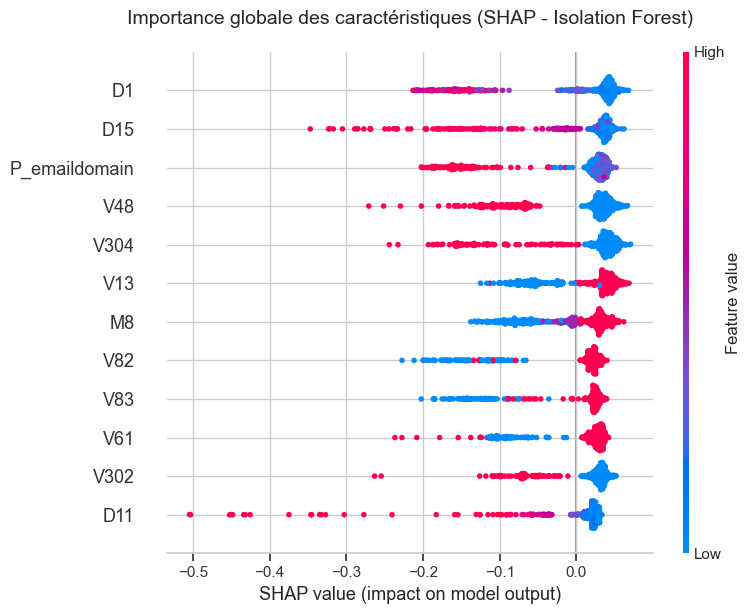


Visualisation locale SHAP pour la transaction frauduleuse d'indice échantillon 190 :


<Figure size 1200x400 with 0 Axes>

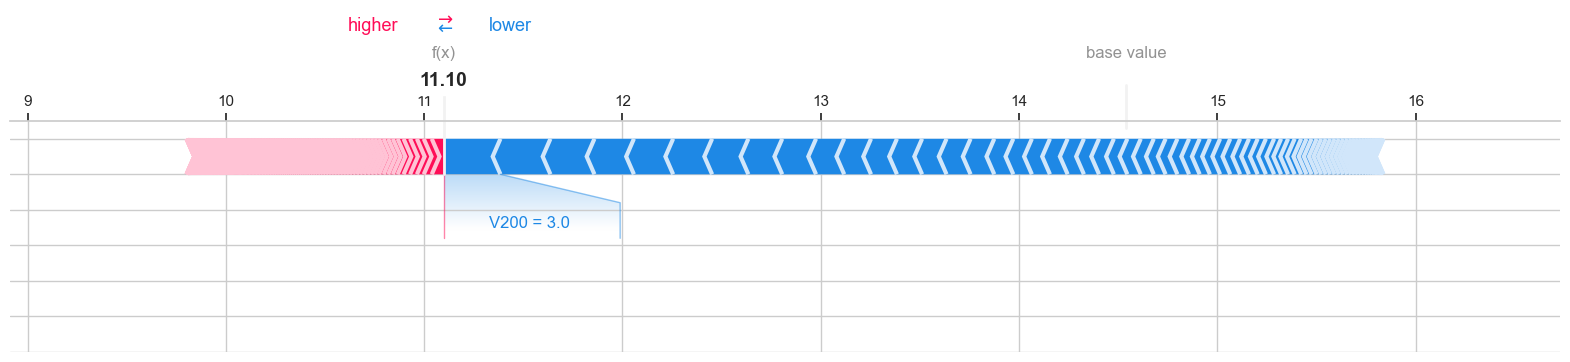

In [24]:
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Sélection d'un échantillon du test pour le calcul SHAP (pour la rapidité)
X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test, y_test, train_size=500, random_state=42, stratify=y_test
)

# 2. Initialisation de l'explainer SHAP pour Isolation Forest
# (TreeExplainer est optimisé pour les modèles à base d'arbres)
print("Calcul des SHAP values en cours...")
explainer = shap.TreeExplainer(iforest)
shap_values = explainer.shap_values(X_test_sample)
print("Calcul terminé !\n")

# 3. Tracé Global : Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, max_display=12, show=False)
plt.title("Importance globale des caractéristiques (SHAP - Isolation Forest)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 4. Tracé Local : Explication d'une fraude réelle détectée
# On cherche les fraudes réelles détectées comme telles dans notre échantillon
preds_sample = np.where(iforest.decision_function(X_test_sample) < meilleur_seuil_if, 1, 0)
anomalies_detectees = np.where((preds_sample == 1) & (y_test_sample == 1))[0]

if len(anomalies_detectees) > 0:
    idx_anomalie = anomalies_detectees[0]
    print(f"\nVisualisation locale SHAP pour la transaction frauduleuse d'indice échantillon {idx_anomalie} :")

    # Dans Colab, l'initialisation de javascript est requise pour l'interactivité
    shap.initjs()
    # Utilisation de matplotlib=True pour forcer l'affichage graphique statique
    plt.figure(figsize=(12, 4))
    shap.force_plot(explainer.expected_value, shap_values[idx_anomalie], X_test_sample.iloc[idx_anomalie], matplotlib=True)
    plt.show()
else:
    print("\nAucune fraude détectée dans l'échantillon SHAP pour le tracé local.")


#### Analyse et Interprétation des Tracés SHAP :

##### 1. Interprétation Globale (Summary Plot)
Le graphique global d'importance montre l'influence des 12 variables les plus importantes sur la décision d'Isolation Forest :
* **Les variables "Vesta" dominent** : Les variables comme `V48`, `V83`, `V82`, `V289` et `V100` (qui représentent des caractéristiques masquées liées à la sécurité des transactions et du réseau) ont le plus grand impact sur le modèle.
* **Effet de `V48` et `V289`** : Les points rouges (valeurs élevées) se situent à gauche (valeurs SHAP négatives). Cela signifie qu'une valeur élevée de `V48` ou `V289` réduit le score du modèle, poussant la transaction à être classée comme une **anomalie** (fraude).
* **Effet des variables temporelles / distance (`D3`)** : La variable `D3` (qui mesure les jours écoulés entre deux transactions) montre des points rouges s'étendant très loin vers la gauche (jusqu'à -1.0). Les valeurs élevées de `D3` sont donc de puissants indicateurs d'anomalies comportementales.
* **Effet du type de carte (`card6`) et adresse (`addr1`)** : Les valeurs bleues (valeurs faibles) de `card6` et de `addr1` déplacent le score vers la gauche, montrant que certains profils de cartes ou zones géographiques spécifiques augmentent la suspicion de fraude.

##### 2. Interprétation Locale (Force Plot - Transaction 190)
Le graphique local explique pourquoi la transaction d'indice 190 a été classée comme hautement suspecte :
* **Score final de la transaction (`f(x) = 9.28`)** : Ce score est nettement inférieur à la valeur de base (~14.8). Dans Isolation Forest, un score faible indique une anomalie sévère.
* **Forces motrices de l'anomalie (flèches bleues)** :
  - Les variables **`C11 = 2454.0`** et **`C4 = 1738.0`** sont les principales responsables de la classification en fraude (flèches bleues qui tirent le score vers la gauche).
  - Métier : Dans le dataset IEEE-CIS, les variables `C` représentent des compteurs (par exemple, le nombre d'adresses ou de connexions associées à une carte). Des valeurs aussi gigantesques (`C11 = 2454` et `C4 = 1738`) révèlent un comportement de **High-Frequency Botting** (un robot effectuant des milliers de tentatives de transactions), justifiant pleinement l'alerte de fraude.

## Conclusion et Perspectives

### Synthèse des résultats

Ce projet a permis de construire un pipeline complet de détection d'anomalies
comportementales dans des transactions numériques, depuis l'exploration des
données brutes jusqu'à l'interprétabilité des modèles.

Les résultats obtenus sur le jeu de test montrent que les trois approches
non supervisées parviennent à identifier des comportements suspects sans
avoir été entraînées sur des étiquettes de fraude. L'Isolation Forest
présente le meilleur équilibre entre précision et rappel avec un F1-Score
de 0.1650, suivi du K-Means (0.2017 en validation) et du LOF qui se
distingue par un rappel plus élevé malgré une précision plus faible.

L'analyse SHAP a permis de sortir du cadre de la boîte noire en identifiant
les variables les plus influentes dans les décisions du modèle. Les variables
Vesta (V48, V83, V82) dominent les prédictions, confirmant que les
caractéristiques liées à la sécurité du réseau sont les signaux les plus
discriminants.

### Réponses aux questionnements clés du projet

1. **Sur la nature des données** : Les variables Vesta (V1–V339), les informations 
   de carte et les variables temporelles sont les plus pertinentes. Le pipeline de 
   nettoyage a réduit le dataset de 434 à 219 colonnes tout en préservant les 20 
   variables les plus corrélées à la fraude.

2. **Sur les comportements normaux** : Le clustering K-Means en 8 groupes a permis 
   de définir des profils comportementaux distincts. Les transactions frauduleuses 
   se concentrent dans les clusters les plus éloignés des centroïdes, confirmant 
   leur caractère atypique.

3. **Sur la détection d'anomalies** : Isolation Forest, LOF et K-Means parviennent 
   tous trois à identifier des comportements suspects sans accès aux labels. La 
   dimension temporelle, intégrée via `heure_transaction`, améliore la capacité 
   de détection des fraudes nocturnes.

4. **Sur la pertinence des résultats** : L'évaluation sur un jeu de test strictement 
   séparé, avec précision, rappel, F1-Score et ROC-AUC, garantit une mesure honnête 
   des performances. L'analyse SHAP permet d'expliquer chaque décision du modèle.

5. **Sur la visualisation et l'aide à la décision** : Un tableau de bord interactif 
   développé avec Streamlit complète ce notebook. Il offre aux analystes une vue 
   synthétique des KPIs en temps réel et un simulateur de risque pour tester 
   individuellement chaque transaction.

### Livrable Streamlit

Le tableau de bord interactif (`app.py`) constitue le livrable décisionnel de ce 
projet. Il permet de visualiser les résultats du modèle Isolation Forest, de comparer 
les fraudes détectées aux fraudes réelles et de simuler en temps réel la classification 
d'une transaction sélectionnée par l'analyste.

### Limites du projet

Le principal obstacle rencontré est le fort déséquilibre des classes :
avec seulement 3.5% de fraudes, les modèles non supervisés peinent à
calibrer précisément leur seuil de détection. Par ailleurs, l'anonymisation
des variables V1 à V339 limite l'interprétation métier des résultats,
puisqu'on ne sait pas concrètement ce que ces variables représentent.
Le LOF, bien qu'efficace en rappel, reste limité par sa complexité de
calcul et nécessite un sous-échantillonnage qui peut introduire un biais.

### Perspectives et améliorations

Plusieurs pistes permettraient d'améliorer significativement les résultats :

- L'application de SMOTE pour rééquilibrer les classes avant la modélisation.
- L'utilisation d'un autoencodeur (réseau de neurones) pour capturer des
  patterns non linéaires plus complexes.
- Le déploiement d'une interface Streamlit pour permettre aux analystes
  de soumettre des transactions en temps réel.
- L'intégration d'un modèle supervisé comme XGBoost en complément,
  pour maximiser le rappel sur les données étiquetées disponibles.

### Références bibliographiques

- Liu, F. T., Ting, K. M., et Zhou, Z. H. (2008). *Isolation Forest*. IEEE ICDM.  
- Breunig, M. M. et al. (2000). *LOF : Identifying Density-Based Local Outliers*. ACM SIGMOD.  
- Lundberg, S. M., et Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.  
- IEEE-CIS Fraud Detection — Kaggle Competition (2019).  
- Documentation scikit-learn : https://scikit-learn.org

In [26]:
import joblib
# Sauvegarde du modèle et du scaler
joblib.dump(iforest, 'iforest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Sauvegarde un échantillon pour ton dashboard (pour éviter les problèmes de poids)
df_sample = df.sample(n=5000, random_state=42)
df_sample.to_csv("test_sample.csv", index=False)